In [32]:
import pandas as pd
import scanpy as sc
import anndata as ad
from pathlib import Path

## Filter Knockout Sample

In [33]:
figdir = Path("/gpfs/Home/esm5360/bulk_rna_seq_analysis/figures/KO_preprocessing")
figdir.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(figdir)

### Read in the data file and remove duplicate variables

In [34]:
ko_raw_adata = sc.read_10x_h5("/gpfs/Labs/Uzun/DATA/PROJECTS/2026.RSV.R03.CHINTAN/SC_RNA_SEQ/CELLRANGER_OUTPUTS/BATCH_2026_02/KO_Sample01/outs/filtered_feature_bc_matrix.h5")
ko_raw_adata.var_names_make_unique()
ko_raw_adata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 8848 × 22339
    var: 'gene_ids', 'feature_types', 'genome'

### Filter out low-quality cells and genes

In [35]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
ko_raw_adata.var["mt"] = ko_raw_adata.var_names.str.upper().str.startswith("MT-")
# ribosomal genes
ko_raw_adata.var["ribo"] = ko_raw_adata.var_names.str.upper().str.startswith(("RPS", "RPL"))
# hemoglobin genes
ko_raw_adata.var["hb"] = ko_raw_adata.var_names.str.upper().str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(ko_raw_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

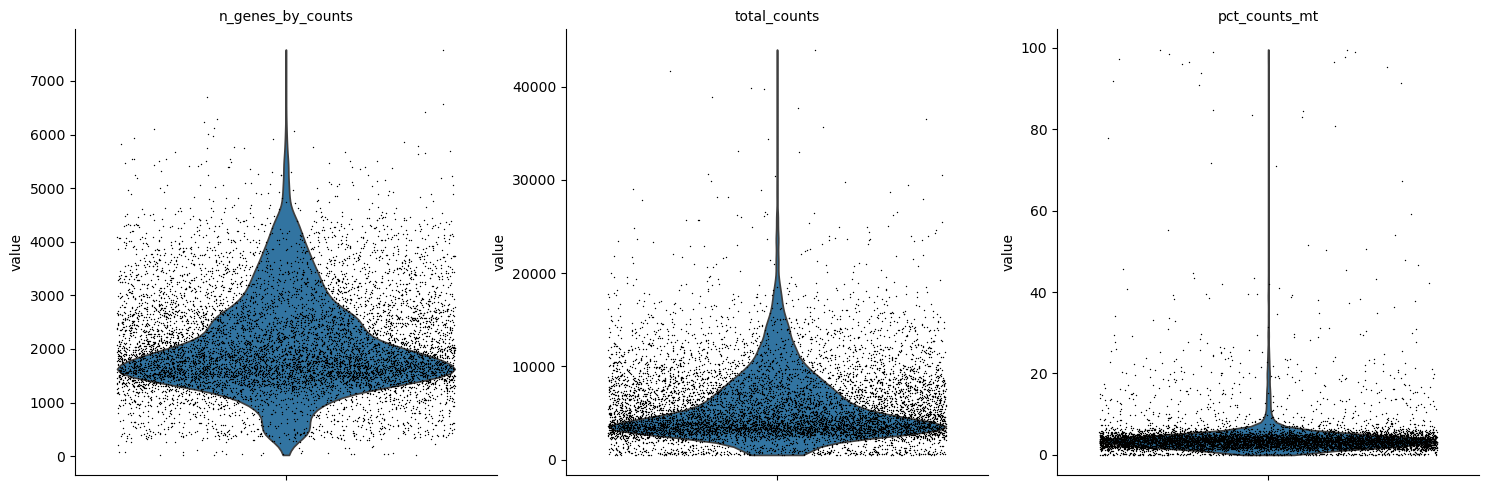

In [36]:
sc.pl.violin(
    ko_raw_adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_before_processing.png",
)

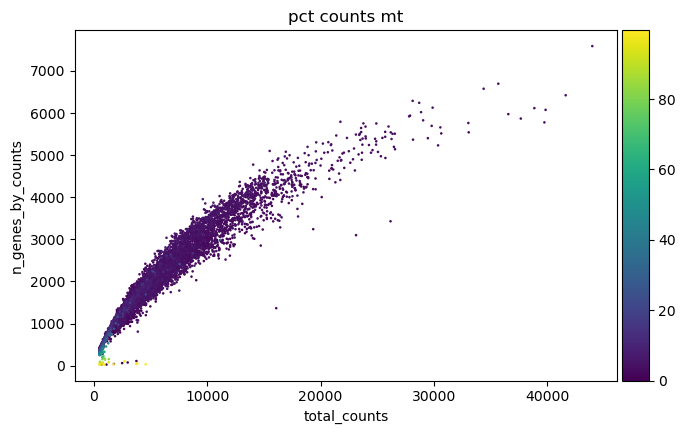

In [37]:
sc.pl.scatter(
    ko_raw_adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", save="qc_scatter_before_processing.png")

In [38]:
min_expressed_genes = 500
max_expressed_genes = 10000
min_UMI = 1000
max_UMI = 20000
max_mit_pct = 10

ko_filtered_adata = ko_raw_adata.copy()

sc.pp.filter_cells(ko_filtered_adata, min_genes=min_expressed_genes)
sc.pp.filter_cells(ko_filtered_adata, max_genes=max_expressed_genes)
sc.pp.filter_genes(ko_filtered_adata, min_cells=min_UMI)
sc.pp.filter_genes(ko_filtered_adata, max_cells=max_UMI)

ko_filtered_adata = ko_filtered_adata[ko_filtered_adata.obs["pct_counts_mt"] < max_mit_pct]

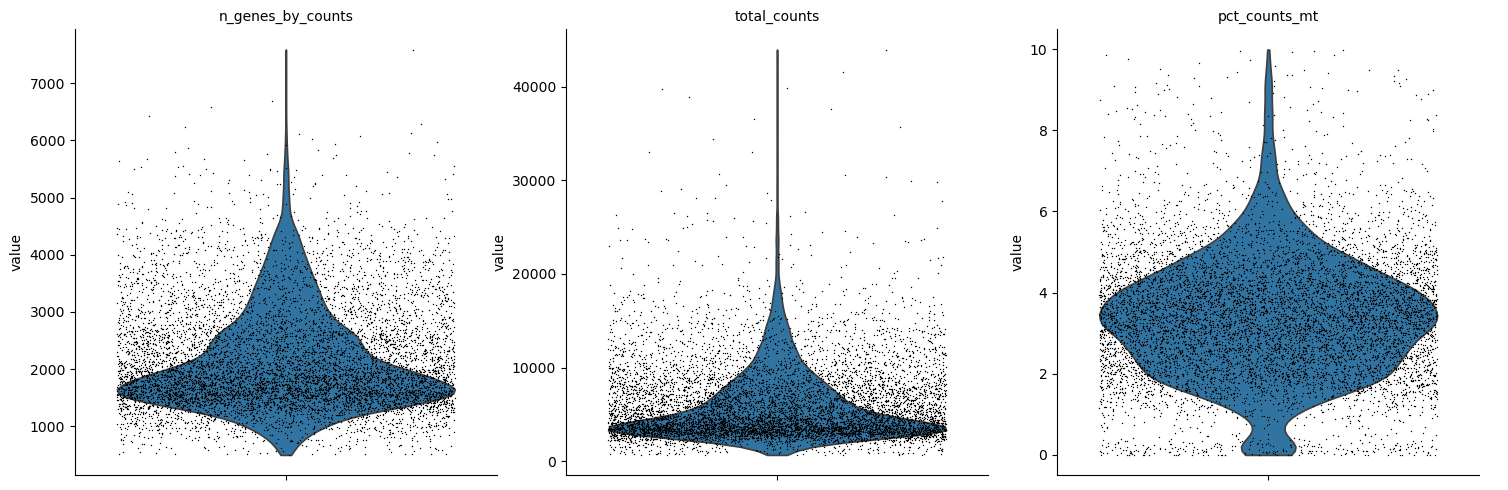

In [39]:
sc.pl.violin(
    ko_filtered_adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_after_processing.png",
)

### Remove doublets

In [40]:
sc.pp.scrublet(ko_filtered_adata)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_scrublet/__init__.py:295: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["doublet_score"] = scrubbed["obs"]["doublet_score"]


In [41]:
# Saving count data
ko_filtered_adata.layers["counts"] = ko_filtered_adata.X.copy()

### Scale / normalize / select highly-varible genes

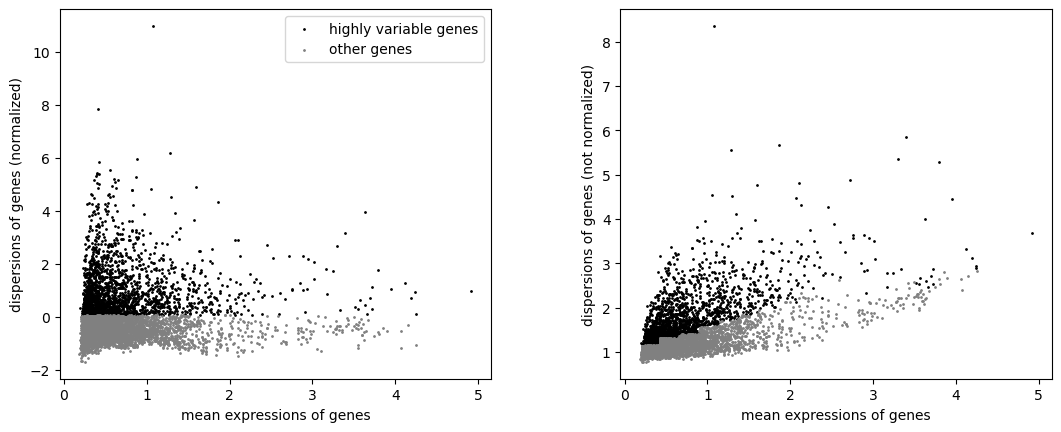

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [42]:
# Normalize + log (Seurat NormalizeData)
sc.pp.normalize_total(ko_filtered_adata, target_sum=1e4)
sc.pp.log1p(ko_filtered_adata)

# HVG selection (Seurat FindVariableFeatures)
sc.pp.highly_variable_genes(ko_filtered_adata, flavor='seurat', n_top_genes=2000)
sc.pl.highly_variable_genes(ko_filtered_adata, save="_hvg.png")

# Subset to HVGs
ko_filtered_adata = ko_filtered_adata[:, ko_filtered_adata.var.highly_variable]

# Scale (Seurat ScaleData)
sc.pp.scale(ko_filtered_adata, max_value=10)

### Clustering and dimensionality reduction

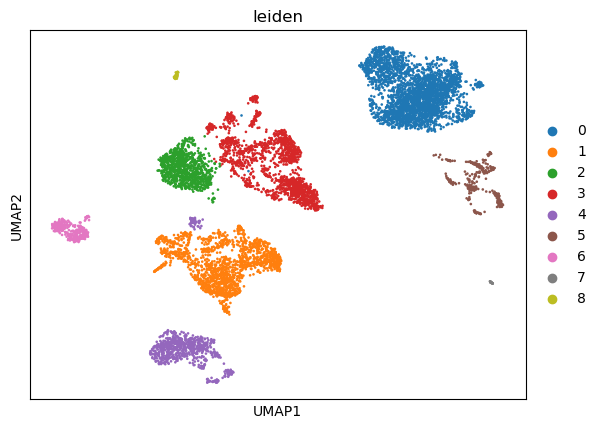

In [43]:
# PCA (Seurat RunPCA)
sc.pp.pca(ko_filtered_adata, n_comps=50)

# Neighbors (Seurat FindNeighbors)
sc.pp.neighbors(ko_filtered_adata, n_neighbors=10, n_pcs=40)

# Find clusters (Seurat FindClusters)
sc.tl.leiden(ko_filtered_adata, resolution=0.1, flavor="igraph") 

# Visualize
sc.tl.umap(ko_filtered_adata)
sc.pl.umap(ko_filtered_adata, color=['leiden'])

### Color clusters by doublets / counts

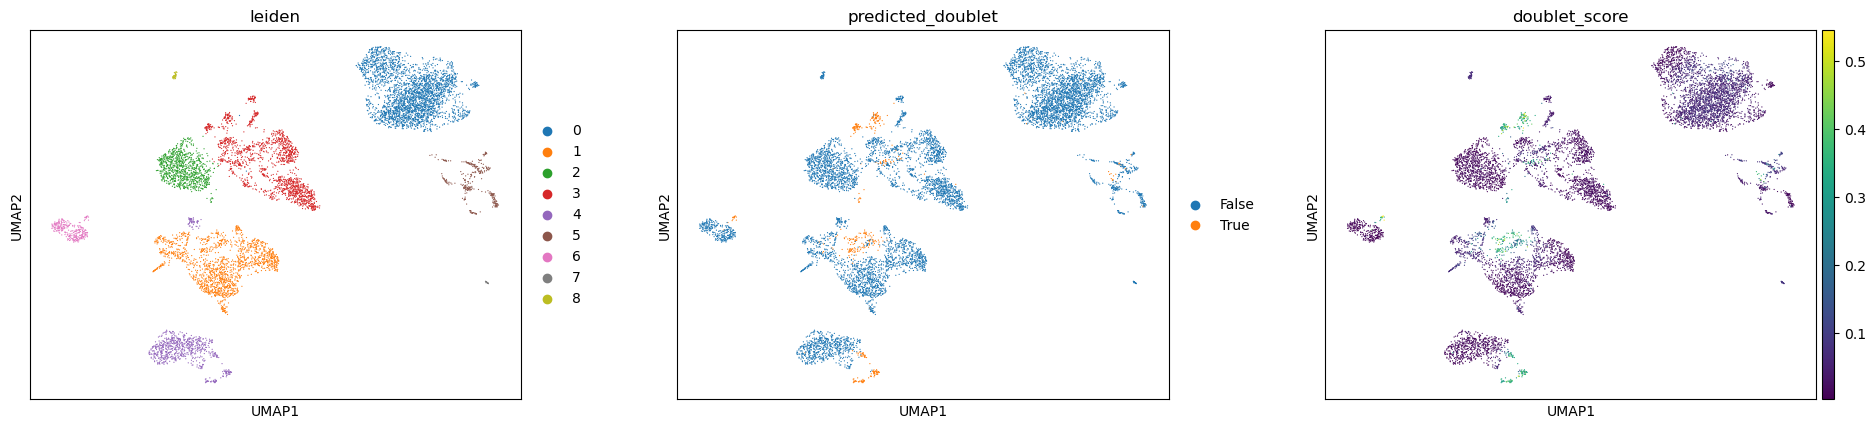

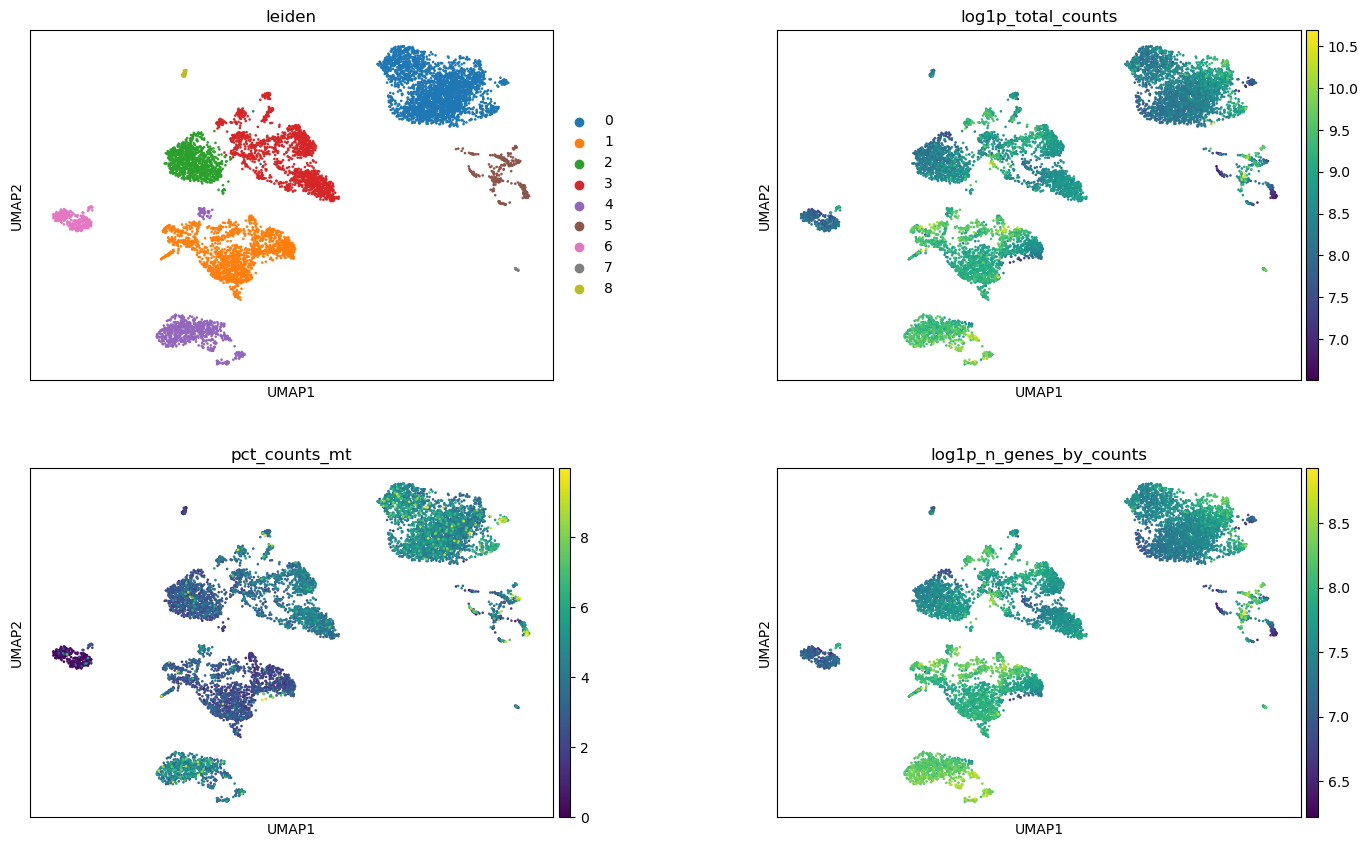

In [44]:
# Look at how the doublet scores and predicted doublets are distributed across clusters
sc.pl.umap(
    ko_filtered_adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.2,
    size=3,
    save="_doublets.png",
)

sc.pl.umap(
    ko_filtered_adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.3,
    ncols=2,
    save="_qc_metrics.png",
)

### Filter out predicted doublets

In [45]:
ko_filtered_adata = ko_filtered_adata[ko_filtered_adata.obs["predicted_doublet"] == False]

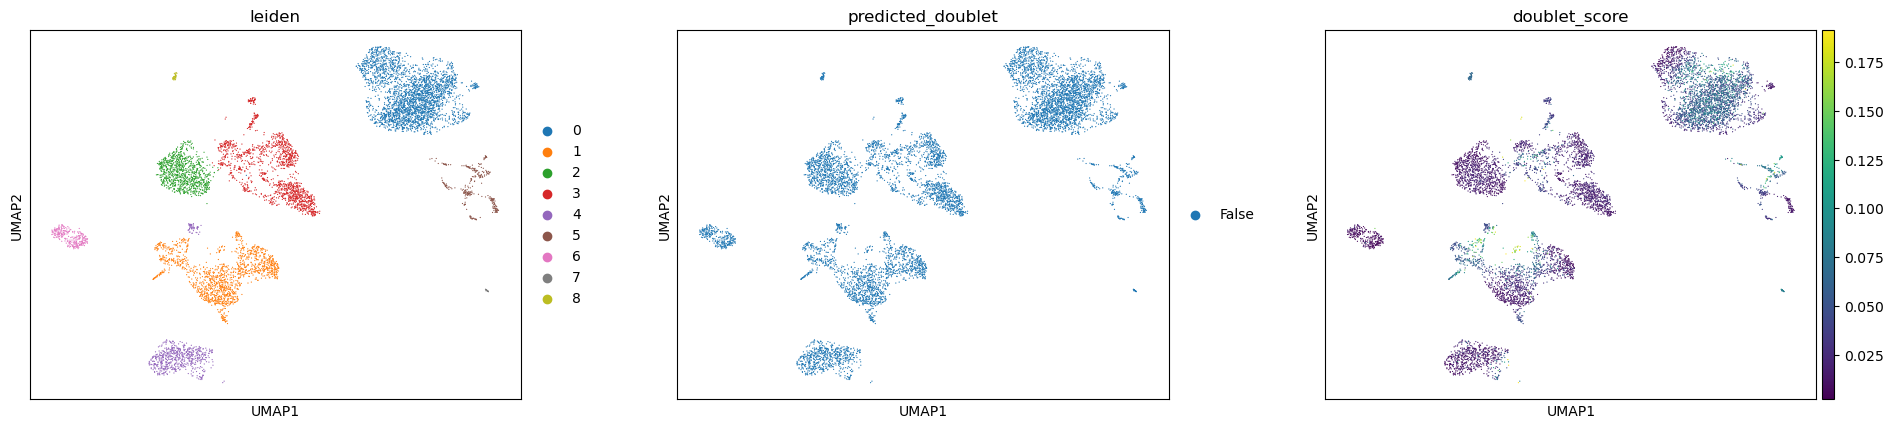

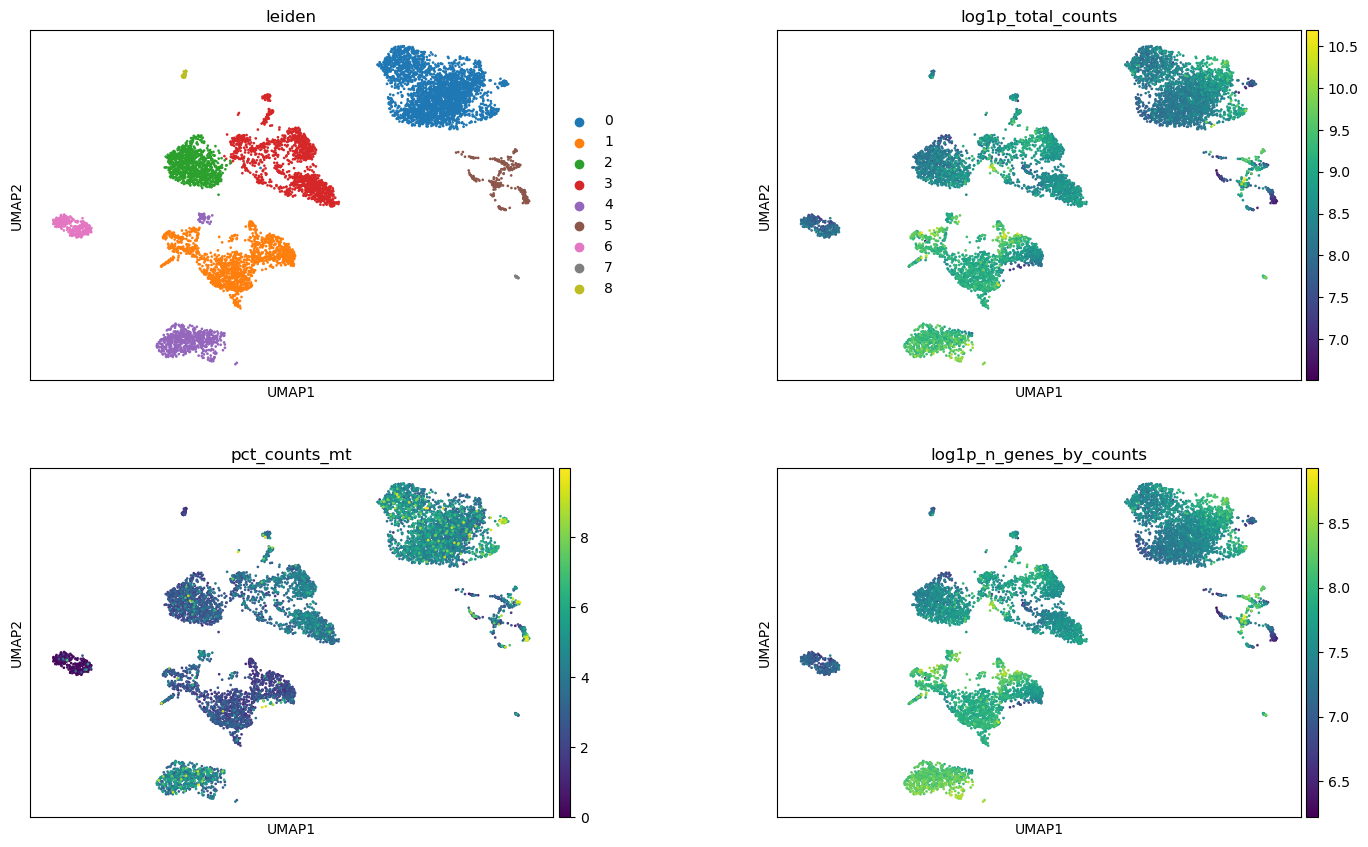

In [46]:
# Look at how the doublet scores and predicted doublets are distributed across clusters
sc.pl.umap(
    ko_filtered_adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.2,
    size=3,
)

sc.pl.umap(
    ko_filtered_adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.3,
    ncols=2,
)

### Check clustering resolution

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_leiden.py:196: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


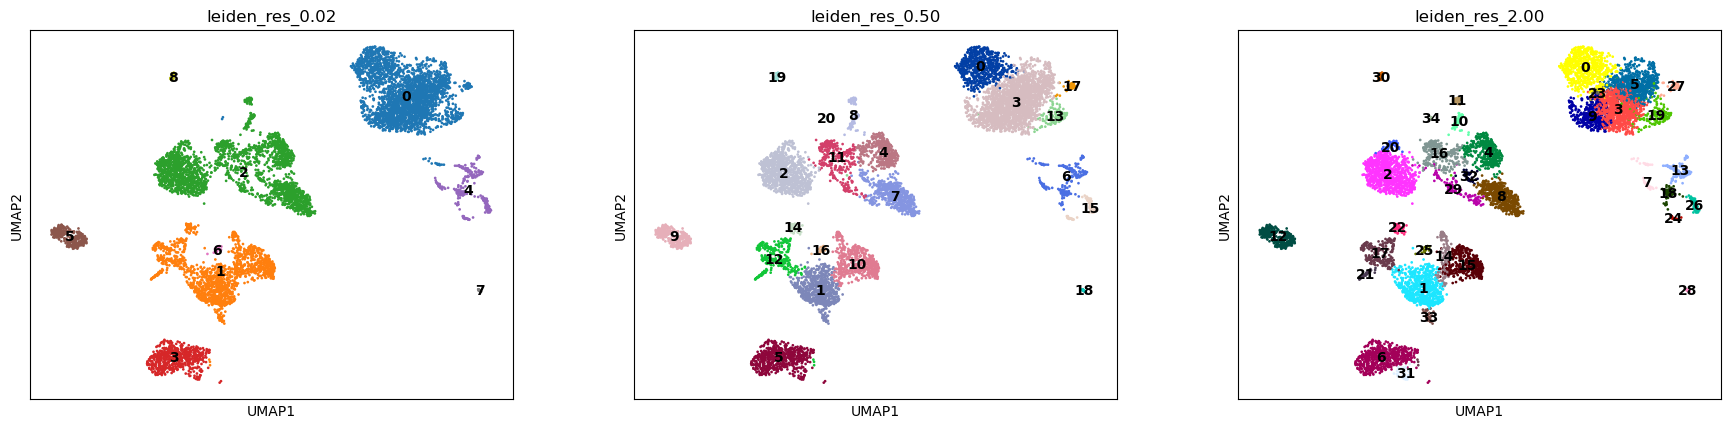

In [47]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(ko_filtered_adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")
    
sc.pl.umap(
    ko_filtered_adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
    save="_leiden_resolution.png"
)

### Save filtered data

In [ ]:
ko_filtered_adata.write_h5ad("/gpfs/Home/esm5360/bulk_rna_seq_analysis/data/ko_filtered_adata.h5ad")